/home/aadit/Projects/Optimized-Hybrid-Initialization-for-Deep-CNNs/.venv/lib/python3.13/site-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Epoch [1/20], Train Loss: 1.1959, Train Acc: 44.20%, Val Loss: 0.7986, Val Acc: 67.72%


Epoch [2/20], Train Loss: 0.5507, Train Acc: 78.94%, Val Loss: 0.4248, Val Acc: 84.58%


Epoch [3/20], Train Loss: 0.3432, Train Acc: 87.93%, Val Loss: 0.3564, Val Acc: 87.47%


Epoch [4/20], Train Loss: 0.2635, Train Acc: 91.00%, Val Loss: 0.3932, Val Acc: 86.69%


...

Epoch [17/20], Train Loss: 0.0198, Train Acc: 99.36%, Val Loss: 0.6138, Val Acc: 89.43%


Epoch [18/20], Train Loss: 0.0176, Train Acc: 99.42%, Val Loss: 0.6998, Val Acc: 88.49%


Epoch [19/20], Train Loss: 0.0160, Train Acc: 99.50%, Val Loss: 0.6122, Val Acc: 89.81%


Epoch [20/20], Train Loss: 0.0152, Train Acc: 99.50%, Val Loss: 0.6480, Val Acc: 89.56%


Test Accuracy: 89.33%


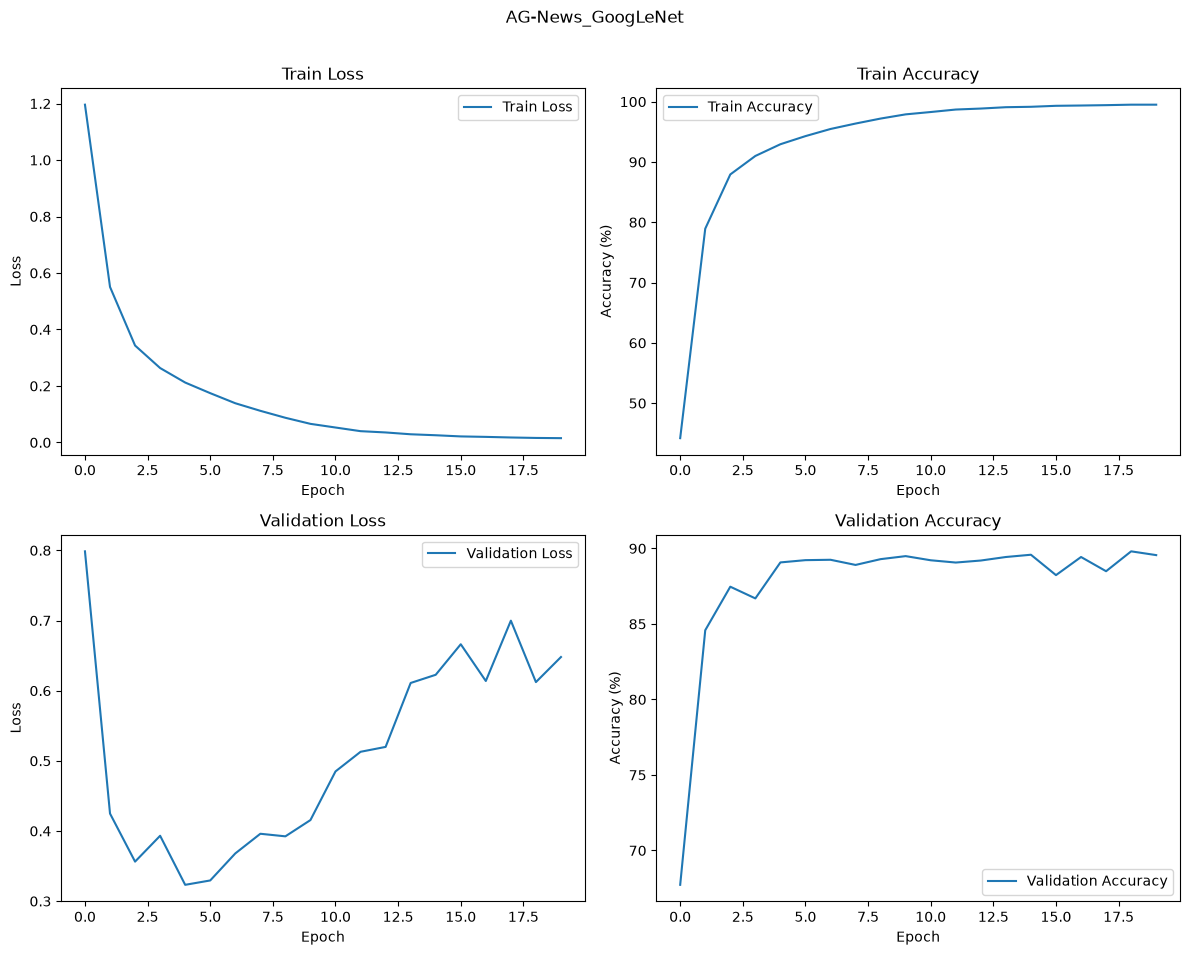

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import googlenet
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

run_name = 'AG-News_GoogLeNet'

# Text converges (and overfits) much faster than the image benchmarks
num_epochs = 20
batch_size = 128
learning_rate = 0.001

import csv
import os
import re
import urllib.request
from collections import Counter

max_len = 64
embed_dim = 64
vocab_limit = 50000

# Download AG News (4-class news topic classification)
base_url = 'https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/'
os.makedirs('./data/ag_news', exist_ok=True)
for split in ['train', 'test']:
    path = f'./data/ag_news/{split}.csv'
    if not os.path.exists(path):
        print(f'Downloading {split}.csv...')
        urllib.request.urlretrieve(base_url + f'{split}.csv', path)

def load_split(path):
    texts, labels = [], []
    with open(path, encoding='utf-8') as f:
        for row in csv.reader(f):
            labels.append(int(row[0]) - 1)
            texts.append((row[1] + ' ' + row[2]).lower())
    return texts, labels

train_texts, train_labels = load_split('./data/ag_news/train.csv')
test_texts, test_labels = load_split('./data/ag_news/test.csv')

def tokenize(text):
    return re.findall(r"[a-z0-9']+", text)

# Build vocabulary from the training split
counter = Counter()
for text in train_texts:
    counter.update(tokenize(text))

vocab = {'<pad>': 0, '<unk>': 1}
for word, _ in counter.most_common(vocab_limit - 2):
    vocab[word] = len(vocab)

def encode(text):
    ids = [vocab.get(tok, 1) for tok in tokenize(text)][:max_len]
    ids += [0] * (max_len - len(ids))
    return ids

class AGNewsDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.data = torch.tensor([encode(t) for t in texts], dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

train_dataset = AGNewsDataset(train_texts, train_labels)
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

test_dataset = AGNewsDataset(test_texts, test_labels)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Hybrid Initialization (He for Conv2d, Orthogonal for Linear)
def custom_init(model):
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
        elif isinstance(module, nn.Linear):
            nn.init.orthogonal_(module.weight)
        if hasattr(module, 'bias') and module.bias is not None:
            nn.init.constant_(module.bias, 0)

# GoogLeNet over the embedded token map, treated as a 1-channel image
# (first conv adapted to 1 channel, same pattern as the QMNIST notebook)
class GoogLeNetText(nn.Module):
    def __init__(self):
        super(GoogLeNetText, self).__init__()

        self.embedding = nn.Embedding(len(vocab), embed_dim, padding_idx=0)
        self.googlenet = googlenet(num_classes=4, aux_logits=False)

        self.googlenet.conv1.conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    def forward(self, x):
        x = self.embedding(x)
        x = x.unsqueeze(1)
        return self.googlenet(x)

model = GoogLeNetText().to(device)
custom_init(model)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_loss_list = []
train_acc_list = []
val_loss_list = []
val_acc_list = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_loss_list.append(val_loss / len(val_loader))
    val_acc_list.append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss_list[-1]:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss_list[-1]:.4f}, Val Acc: {val_acc:.2f}%')

correct = 0
total = 0
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f'Test Accuracy: {test_acc:.2f}%')

# Save metrics to files labelled with dataset + model name
with open(f'{run_name}_metrics.csv', 'w') as f:
    f.write('epoch,train_loss,train_acc,val_loss,val_acc\n')
    for i in range(num_epochs):
        f.write(f'{i+1},{train_loss_list[i]:.6f},{train_acc_list[i]:.4f},{val_loss_list[i]:.6f},{val_acc_list[i]:.4f}\n')

with open(f'{run_name}_test_accuracy.txt', 'w') as f:
    f.write(f'{run_name} Test Accuracy: {test_acc:.2f}%\n')

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(train_acc_list, label='Train Accuracy')
plt.title('Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(val_loss_list, label='Validation Loss')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(val_acc_list, label='Validation Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.suptitle(run_name)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig(f'{run_name}_curves.png', dpi=150)
plt.show()